# EDA

## Data Preparation
- Importing the PyTorch and TorchVision libraries
- Preparing transformations for CIFAR-10 data
- Creating a CIFAR-10 training set with automatic data download

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), 
                         (0.5, 0.5, 0.5))
    ])

train_dataset = datasets.CIFAR10(
    root="../data",
    download=True,
    train=True,
    transform=transform
    )


## There are 10 classes

In [5]:
train_dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

## Dataset is balanced (5000 samples per class)

In [25]:
labels = torch.tensor([label for _, label in train_dataset])

class_counts = torch.bincount(labels)
for i, count in enumerate(class_counts):
    print(f"Class {i}: {count}")

Class 0: 5000
Class 1: 5000
Class 2: 5000
Class 3: 5000
Class 4: 5000
Class 5: 5000
Class 6: 5000
Class 7: 5000
Class 8: 5000
Class 9: 5000


## There is relatively little data

In [6]:
len(train_dataset)

50000

## The images are small (32x32), which may make classification difficult

In [11]:
image, label = train_dataset[0]
print(image.shape)

torch.Size([3, 32, 32])


## Potential problems in prediction
- There is high variability within classes (e.g., birds)
- Background may affect model predictions

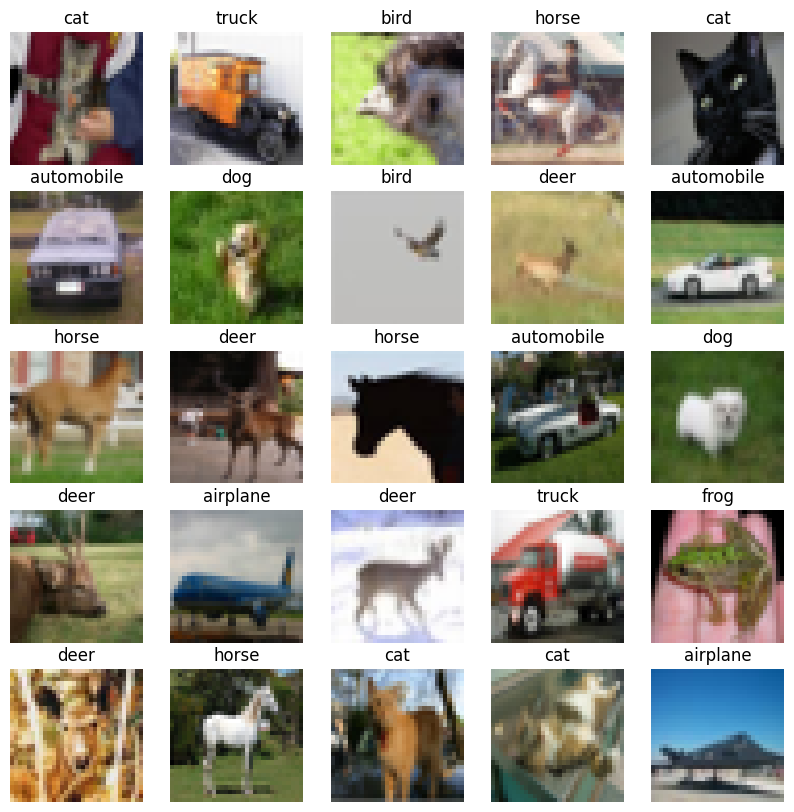

In [7]:
import matplotlib.pyplot as plt
import numpy as np

figure = plt.figure(figsize=(10,10))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_id = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_id]
    figure.add_subplot(rows, cols, i)
    plt.title(train_dataset.classes[label])
    plt.axis("off")
    img = img.permute(1, 2, 0) 
    img = img * 0.5 + 0.5      
    img = img.numpy()
    plt.imshow(img)
plt.show()

# Data Pipeline Sanity Check

## Preparind data loader

In [3]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
    )

## Dataloader is working properly

In [5]:
images, labels = next(iter(train_dataloader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


## Batch visualization
Batches are suitable for training because they are varied

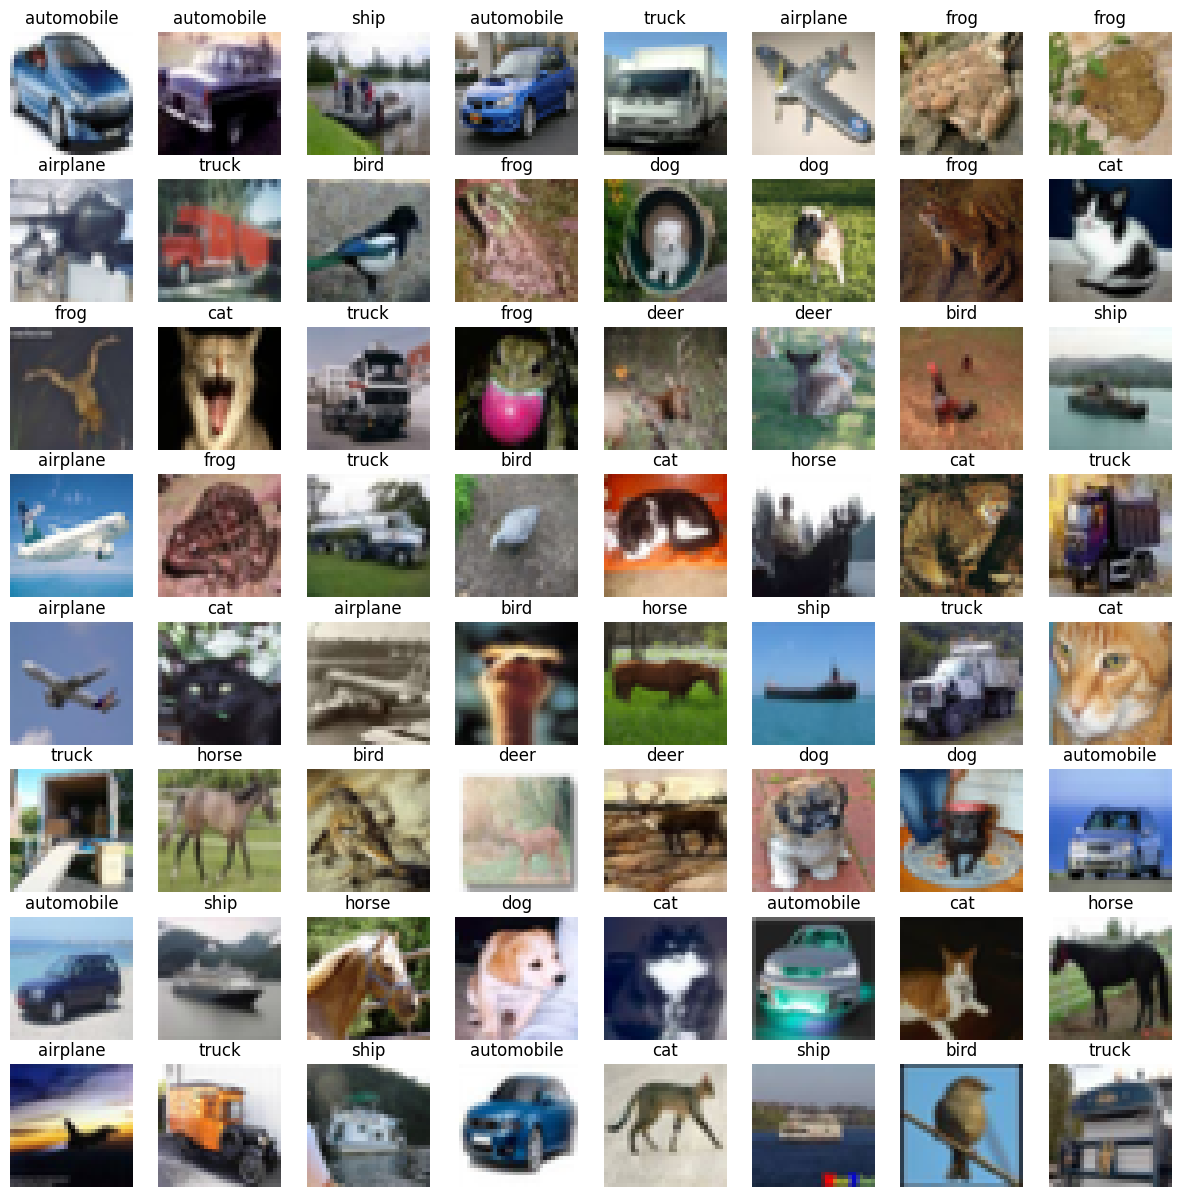

In [21]:
class_names = train_dataset.classes

figure = plt.figure(figsize=(15,15))
cols, rows = 8, 8
for i in range(1, cols * rows + 1):
    label = labels[i - 1].item()
    figure.add_subplot(rows, cols, i)
    plt.title(class_names[label])
    plt.axis("off")
    img = images[i - 1].permute(1, 2, 0) 
    img = img * 0.5 + 0.5      
    img = img.numpy()
    plt.imshow(img)
plt.show()

## Normalization is working properly

tensor(-1.) tensor(1.)


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

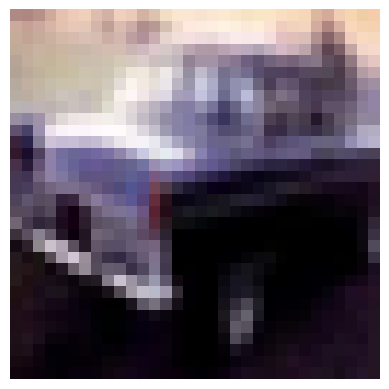

In [34]:
print(images.min(), images.max())

img = images[1].clone()

img = img * 0.5 + 0.5
img = img.permute(1, 2, 0)

plt.imshow(img.numpy())
plt.axis("off")